In [3]:
!pip install xgboost
import numpy as np
import os
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, accuracy_score,
                             roc_curve, auc as sklearn_auc,
                             precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
warnings.filterwarnings('ignore')

BASE_DIR     = r'C:\Users\elent\Downloads\Eye Disease Detection'
FEATURES_DIR = os.path.join(BASE_DIR, 'features')
RESULTS_DIR  = os.path.join(BASE_DIR, 'results')
MODELS_DIR   = os.path.join(BASE_DIR, 'checkpoints')
CLASSES      = ['CNV', 'DME', 'DRUSEN', 'NORMAL']

os.makedirs(RESULTS_DIR, exist_ok=True)
print("Setup done")

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Setup done


In [6]:
print("Loading features...")
train_features = np.load(os.path.join(FEATURES_DIR, 'train_features.npy'))
train_labels   = np.load(os.path.join(FEATURES_DIR, 'train_labels.npy'))
val_features   = np.load(os.path.join(FEATURES_DIR, 'val_features.npy'))
val_labels     = np.load(os.path.join(FEATURES_DIR, 'val_labels.npy'))
test_features  = np.load(os.path.join(FEATURES_DIR, 'test_features.npy'))
test_labels    = np.load(os.path.join(FEATURES_DIR, 'test_labels.npy'))

print(f"Train : {train_features.shape} | Labels: {train_labels.shape}")
print(f"Val   : {val_features.shape}   | Labels: {val_labels.shape}")
print(f"Test  : {test_features.shape}  | Labels: {test_labels.shape}")


Loading features...
Train : (83484, 2048) | Labels: (83484,)
Val   : (32, 2048)   | Labels: (32,)
Test  : (968, 2048)  | Labels: (968,)


In [7]:
counts = Counter(train_labels)
print("\nTraining class distribution:")
for i, cls in enumerate(CLASSES):
    print(f"  {cls}: {counts[i]:,} ({counts[i]/len(train_labels)*100:.1f}%)")


Training class distribution:
  CNV: 37,205 (44.6%)
  DME: 11,348 (13.6%)
  DRUSEN: 8,616 (10.3%)
  NORMAL: 26,315 (31.5%)


In [8]:
total = len(train_labels)
n_classes = len(CLASSES)
sample_weights = np.array([
    total / (n_classes * counts[l]) for l in train_labels
])

print("Class weights computed:")
for i, cls in enumerate(CLASSES):
    w = total / (n_classes * counts[i])
    print(f"  {cls}: {w:.4f}")

Class weights computed:
  CNV: 0.5610
  DME: 1.8392
  DRUSEN: 2.4224
  NORMAL: 0.7931


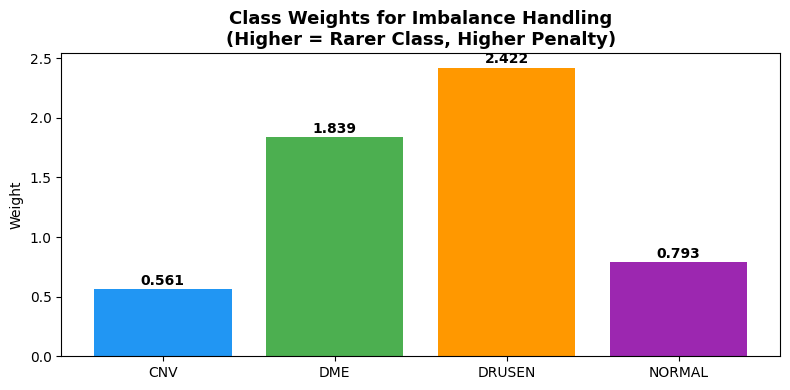

Class weights plot saved!


In [9]:
plt.figure(figsize=(8, 4))
weights = [total / (n_classes * counts[i]) for i in range(n_classes)]
bars = plt.bar(CLASSES, weights, color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
for bar, w in zip(bars, weights):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{w:.3f}', ha='center', va='bottom', fontweight='bold')
plt.title('Class Weights for Imbalance Handling\n(Higher = Rarer Class, Higher Penalty)',
          fontsize=13, fontweight='bold')
plt.ylabel('Weight')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'xgb_class_weights.png'), dpi=150)
plt.show()
print("Class weights plot saved!")

In [10]:
print(" Training XGBoost")
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
    device='cuda',
    verbosity=1
)

xgb.fit(
    train_features, train_labels,
    sample_weight=sample_weights,
    eval_set=[(train_features, train_labels),
              (val_features, val_labels)],
    verbose=50
)

print("\nTraining done")
joblib.dump(xgb, os.path.join(MODELS_DIR, 'xgboost_model.pkl'))
print("Model saved to Drive")

 Training XGBoost
[0]	validation_0-mlogloss:1.30955	validation_1-mlogloss:1.27258
[50]	validation_0-mlogloss:0.46345	validation_1-mlogloss:0.26150
[100]	validation_0-mlogloss:0.31474	validation_1-mlogloss:0.16445
[150]	validation_0-mlogloss:0.22993	validation_1-mlogloss:0.12621
[200]	validation_0-mlogloss:0.17362	validation_1-mlogloss:0.10521
[250]	validation_0-mlogloss:0.13275	validation_1-mlogloss:0.08178
[299]	validation_0-mlogloss:0.10325	validation_1-mlogloss:0.06717

Training done
Model saved to Drive


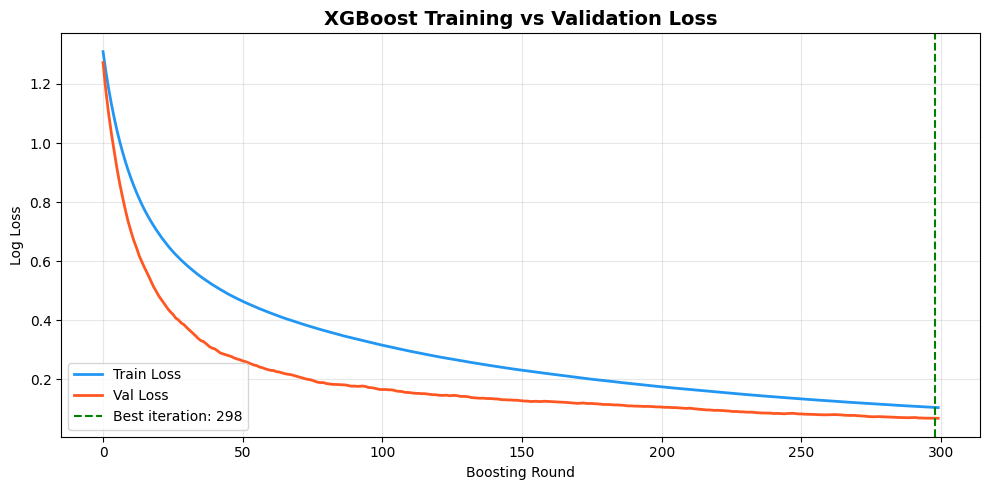

Best iteration: 298
Loss curve saved


In [11]:
results = xgb.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Loss', color='#2196F3', linewidth=2)
plt.plot(val_loss,   label='Val Loss',   color='#FF5722', linewidth=2)
plt.axvline(x=xgb.best_iteration, color='green', linestyle='--',
            label=f'Best iteration: {xgb.best_iteration}')
plt.title('XGBoost Training vs Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Boosting Round')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'xgb_loss_curve.png'), dpi=150)
plt.show()
print(f"Best iteration: {xgb.best_iteration}")
print("Loss curve saved")

In [12]:
def evaluate_model(model, features, labels, split_name='Test'):
    predictions    = model.predict(features)
    probabilities  = model.predict_proba(features)
    accuracy       = accuracy_score(labels, predictions)
    macro_f1       = f1_score(labels, predictions, average='macro')
    labels_bin     = label_binarize(labels, classes=[0, 1, 2, 3])
    auc_roc        = roc_auc_score(labels_bin, probabilities,
                                   multi_class='ovr', average='macro')

    print(f" {split_name} Results")
    print(f"  Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Macro F1 : {macro_f1:.4f}")
    print(f"  AUC-ROC  : {auc_roc:.4f}")
    print(f"\n  Per-class breakdown:")
    print(classification_report(labels, predictions,
                                target_names=CLASSES, digits=4))
    return {
        'accuracy':      accuracy,
        'macro_f1':      macro_f1,
        'auc_roc':       auc_roc,
        'predictions':   predictions,
        'probabilities': probabilities
    }

xgb_val_results  = evaluate_model(xgb, val_features,  val_labels,  'Validation')
xgb_test_results = evaluate_model(xgb, test_features, test_labels, 'Test')

 Validation Results
  Accuracy : 1.0000 (100.00%)
  Macro F1 : 1.0000
  AUC-ROC  : 1.0000

  Per-class breakdown:
              precision    recall  f1-score   support

         CNV     1.0000    1.0000    1.0000         8
         DME     1.0000    1.0000    1.0000         8
      DRUSEN     1.0000    1.0000    1.0000         8
      NORMAL     1.0000    1.0000    1.0000         8

    accuracy                         1.0000        32
   macro avg     1.0000    1.0000    1.0000        32
weighted avg     1.0000    1.0000    1.0000        32

 Test Results
  Accuracy : 0.9928 (99.28%)
  Macro F1 : 0.9928
  AUC-ROC  : 0.9995

  Per-class breakdown:
              precision    recall  f1-score   support

         CNV     0.9837    1.0000    0.9918       242
         DME     1.0000    0.9752    0.9874       242
      DRUSEN     1.0000    0.9959    0.9979       242
      NORMAL     0.9878    1.0000    0.9938       242

    accuracy                         0.9928       968
   macro avg     0

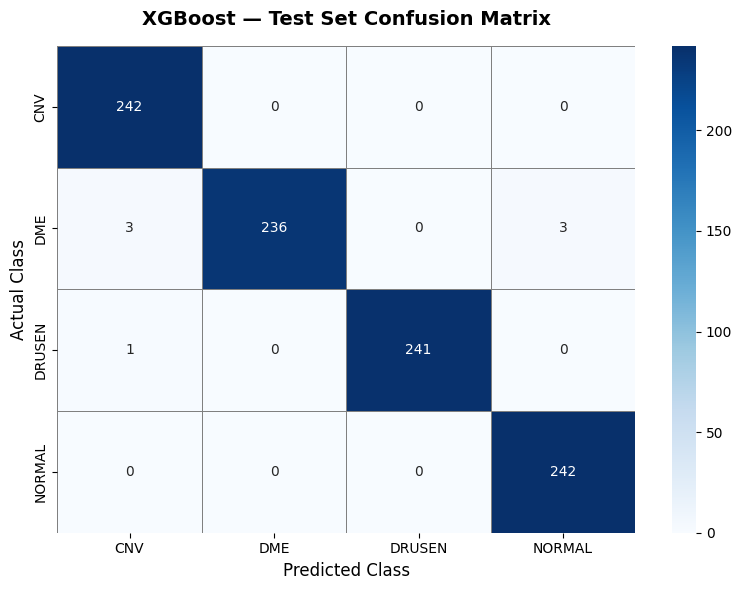

Confusion matrix saved


In [13]:
cm = confusion_matrix(test_labels, xgb_test_results['predictions'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor='gray')
plt.title('XGBoost — Test Set Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'xgb_confusion_matrix.png'), dpi=150)
plt.show()
print("Confusion matrix saved")

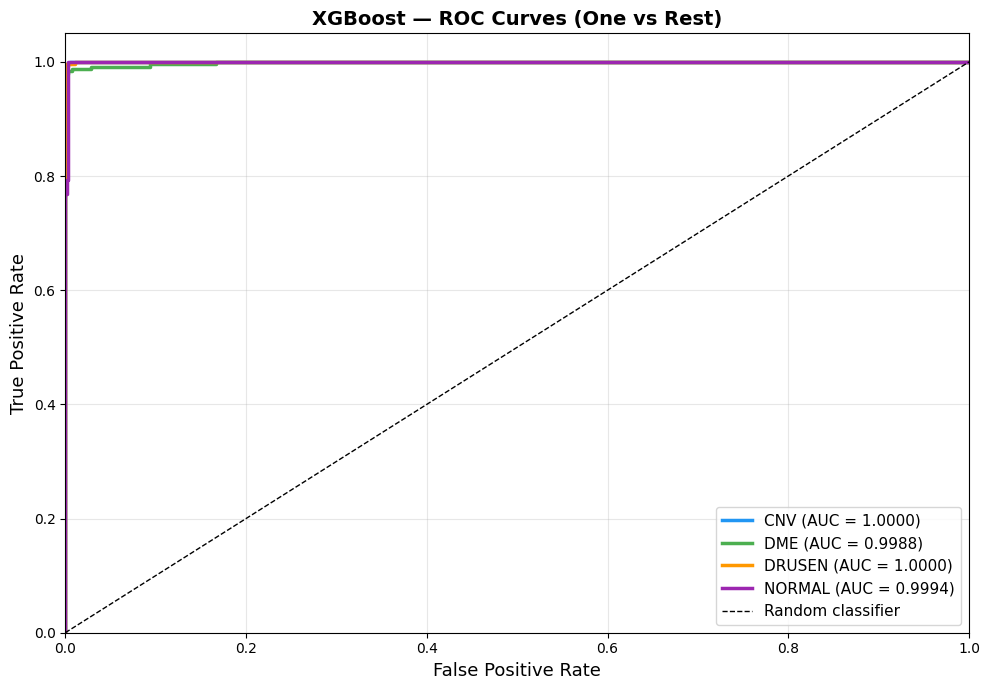

ROC curves saved


In [14]:
labels_bin    = label_binarize(test_labels, classes=[0, 1, 2, 3])
probabilities = xgb_test_results['probabilities']
colors        = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

plt.figure(figsize=(10, 7))
for i, (cls, color) in enumerate(zip(CLASSES, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], probabilities[:, i])
    roc_auc     = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2.5,
             label=f'{cls} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('XGBoost — ROC Curves (One vs Rest)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'xgb_roc_curves.png'), dpi=150)
plt.show()
print("ROC curves saved")

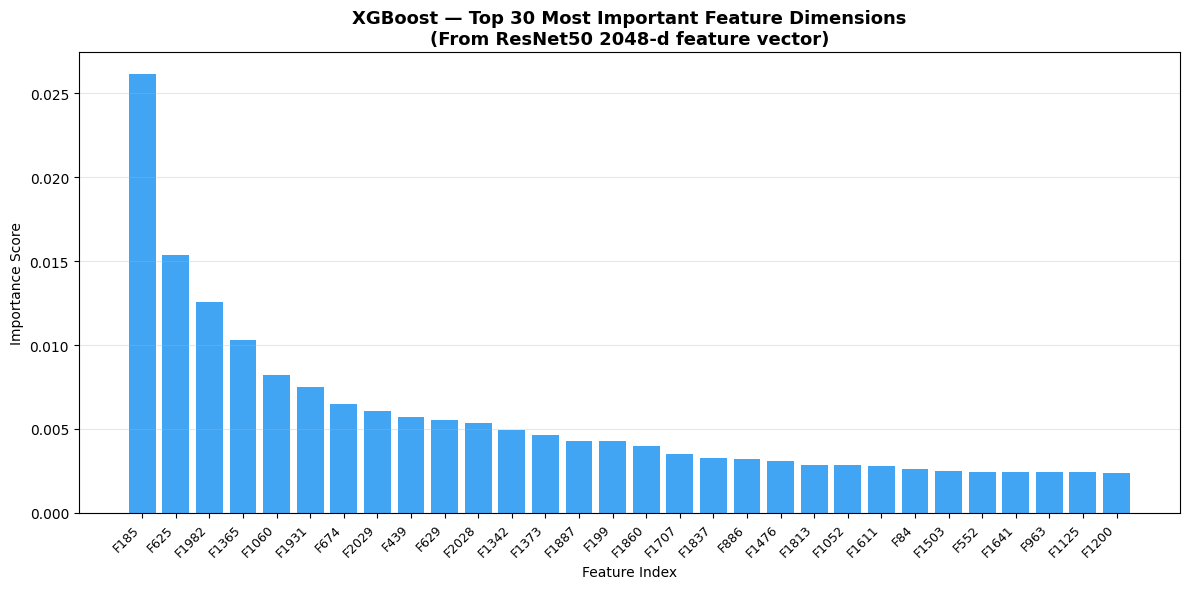

Feature importance plot saved!


In [15]:
importances = xgb.feature_importances_
top_indices = np.argsort(importances)[::-1][:30]
top_values  = importances[top_indices]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(30), top_values, color='#2196F3', alpha=0.85)
plt.xticks(range(30), [f'F{top_indices[i]}' for i in range(30)],
           rotation=45, ha='right', fontsize=9)
plt.title('XGBoost — Top 30 Most Important Feature Dimensions\n(From ResNet50 2048-d feature vector)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Index')
plt.ylabel('Importance Score')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'xgb_feature_importance.png'), dpi=150)
plt.show()
print("Feature importance plot saved!")

In [16]:
if 'xgb_model' not in dir():
    print("Reloading XGBoost model from disk...")
    xgb_model = joblib.load(os.path.join(MODELS_DIR, 'xgboost_model.pkl'))
    print("Model reloaded")

if 'train_features' not in dir() or train_features is None:
    print("Reloading features from disk...")
    train_features = np.load(os.path.join(FEATURES_DIR, 'train_features.npy'))
    train_labels   = np.load(os.path.join(FEATURES_DIR, 'train_labels.npy'))
    test_features  = np.load(os.path.join(FEATURES_DIR, 'test_features.npy'))
    test_labels    = np.load(os.path.join(FEATURES_DIR, 'test_labels.npy'))
    print("Features reloaded")


In [9]:
import hashlib

train_paths_raw = np.load(os.path.join(FEATURES_DIR, 'train_paths.npy'),
                          allow_pickle=True)
test_paths_raw  = np.load(os.path.join(FEATURES_DIR, 'test_paths.npy'),
                          allow_pickle=True)

print(f"Train paths loaded: {len(train_paths_raw)}")
print(f"Test paths loaded : {len(test_paths_raw)}")
print(f"\nSample raw train path: {train_paths_raw[0]}")
print(f"Sample raw test path : {test_paths_raw[0]}")

LOCAL_OCT = os.path.join(BASE_DIR, 'dataset', 'OCT2017')

def remap_path(raw_path, local_oct_root):
    raw_str = str(raw_path)
    marker  = 'OCT2017'
    if marker not in raw_str:
        raise ValueError(f"Could not find '{marker}' in path: {raw_str}")
    suffix   = raw_str.split(marker, 1)[1].lstrip('/').lstrip('\\')
    return os.path.join(local_oct_root, suffix)

train_paths = [remap_path(p, LOCAL_OCT) for p in train_paths_raw]
test_paths  = [remap_path(p, LOCAL_OCT) for p in test_paths_raw]

sample_check = train_paths[0]
if not os.path.exists(sample_check):
    raise FileNotFoundError(
        f"Path remapping failed — file not found: {sample_check}\n"
        f"Check that LOCAL_OCT is correct: {LOCAL_OCT}"
    )
print(f"\nPath remapping verified: {sample_check}")

def md5_hash(filepath):
    h = hashlib.md5()
    with open(filepath, 'rb') as f:
        h.update(f.read())
    return h.hexdigest()

print(f"\nHashing {len(train_paths):,} training images...")
print("(Progress every 20,000 images)")

train_hashes = set()
for i, path in enumerate(train_paths):
    train_hashes.add(md5_hash(path))
    if (i + 1) % 20000 == 0:
        print(f"  Hashed {i+1:,} / {len(train_paths):,}...")

print(f"Hashing complete — {len(train_hashes):,} unique hashes")

print(f"\nChecking {len(test_paths)} test images for leakage...")
leaked_mask  = np.array([md5_hash(p) in train_hashes for p in test_paths])
clean_mask   = ~leaked_mask
total_test   = len(test_labels)
leaked_count = leaked_mask.sum()
clean_count  = clean_mask.sum()

print(" LEAKAGE AUDIT RESULTS")
print(f"  Total test images          : {total_test}")
print(f"  Leaked (identical to train): {leaked_count} ({leaked_count/total_test*100:.1f}%)")
print(f"  Clean (not in train)       : {clean_count}  ({clean_count/total_test*100:.1f}%)")
print("="*60)

if abs(leaked_count - 574) > 20:
    print(f"\nWARNING: Expected ~574 leaked images but found {leaked_count}.")
else:
    print("\nLeakage count matches expected range (~574). Audit looks correct.")

Train paths loaded: 83484
Test paths loaded : 968

Sample raw train path: C:\Users\elent\Downloads\Eye Disease Detection\dataset\OCT2017\train\CNV\CNV-5456083-5.jpeg
Sample raw test path : C:\Users\elent\Downloads\Eye Disease Detection\dataset\OCT2017\test\CNV\CNV-103044-3.jpeg

Path remapping verified: C:\Users\elent\Downloads\Eye Disease Detection\dataset\OCT2017\train\CNV\CNV-5456083-5.jpeg

Hashing 83,484 training images...
(Progress every 20,000 images)
  Hashed 20,000 / 83,484...
  Hashed 40,000 / 83,484...
  Hashed 60,000 / 83,484...
  Hashed 80,000 / 83,484...
Hashing complete — 76,497 unique hashes

Checking 968 test images for leakage...
 LEAKAGE AUDIT RESULTS
  Total test images          : 968
  Leaked (identical to train): 574 (59.3%)
  Clean (not in train)       : 394  (40.7%)

Leakage count matches expected range (~574). Audit looks correct.


In [10]:
full_preds      = xgb_model.predict(test_features)
full_probs      = xgb_model.predict_proba(test_features)
full_acc        = accuracy_score(test_labels, full_preds)
full_f1         = f1_score(test_labels, full_preds, average='macro')
full_labels_bin = label_binarize(test_labels, classes=[0,1,2,3])
try:
    full_auc = roc_auc_score(full_labels_bin, full_probs,
                             multi_class='ovr', average='macro')
except ValueError as e:
    full_auc = float('nan')
    print(f"Full AUC-ROC error: {e}")

clean_features   = test_features[clean_mask]
clean_labels     = test_labels[clean_mask]
clean_preds      = xgb_model.predict(clean_features)
clean_probs      = xgb_model.predict_proba(clean_features)
clean_acc        = accuracy_score(clean_labels, clean_preds)
clean_f1         = f1_score(clean_labels, clean_preds, average='macro')
clean_labels_bin = label_binarize(clean_labels, classes=[0,1,2,3])
try:
    clean_auc = roc_auc_score(clean_labels_bin, clean_probs,
                              multi_class='ovr', average='macro')
except ValueError as e:
    clean_auc = float('nan')
    print(f"Clean AUC-ROC error: {e}")

print(" FULL TEST vs CLEAN TEST — COMPARISON")
print(f"{'Metric':<20} {'Full Test':>12} {'Clean Test':>12} {'Difference':>12}")
print("-"*60)
print(f"{'Sample Count':<20} {total_test:>12} {clean_count:>12} {clean_count-total_test:>12}")
print(f"{'Accuracy':<20} {full_acc*100:>11.2f}% {clean_acc*100:>11.2f}% {(clean_acc-full_acc)*100:>+11.2f}%")
print(f"{'Macro F1':<20} {full_f1:>12.4f} {clean_f1:>12.4f} {clean_f1-full_f1:>+12.4f}")
print(f"{'AUC-ROC':<20} {full_auc:>12.4f} {clean_auc:>12.4f} {clean_auc-full_auc:>+12.4f}")

 FULL TEST vs CLEAN TEST — COMPARISON
Metric                  Full Test   Clean Test   Difference
------------------------------------------------------------
Sample Count                  968          394         -574
Accuracy                   99.28%       98.22%       -1.05%
Macro F1                   0.9928       0.9481      -0.0447
AUC-ROC                    0.9995       0.9983      -0.0012



Clean Test — Per-Class Classification Report:
              precision    recall  f1-score   support

         CNV     0.7778    1.0000    0.8750        14
         DME     1.0000    0.9709    0.9852       206
      DRUSEN     1.0000    0.8889    0.9412         9
      NORMAL     0.9821    1.0000    0.9910       165

    accuracy                         0.9822       394
   macro avg     0.9400    0.9649    0.9481       394
weighted avg     0.9846    0.9822    0.9827       394

Clean test class distribution:
  CNV: 14 (3.6%)
  DME: 206 (52.3%)
  DRUSEN: 9 (2.3%)
  NORMAL: 165 (41.9%)


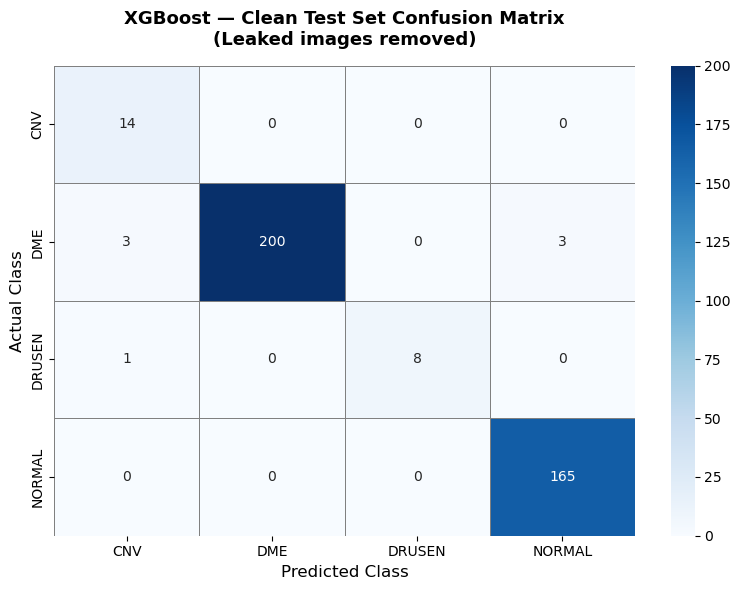

Clean confusion matrix saved


In [11]:
print("\nClean Test — Per-Class Classification Report:")
print(classification_report(clean_labels, clean_preds,
                            target_names=CLASSES, digits=4))

print("Clean test class distribution:")
clean_dist = Counter(clean_labels)
for i, cls in enumerate(CLASSES):
    count = clean_dist[i]
    print(f"  {cls}: {count} ({count/clean_count*100:.1f}%)")

cm_clean = confusion_matrix(clean_labels, clean_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            linewidths=0.5, linecolor='gray')
plt.title('XGBoost — Clean Test Set Confusion Matrix\n(Leaked images removed)',
          fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Actual Class', fontsize=12)
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'xgb_clean_test_confusion.png'), dpi=150)
plt.show()
print("Clean confusion matrix saved")


 CONFIDENCE DISTRIBUTION ANALYSIS

  Full Test Set:
    Correct   — Mean confidence : 95.0%  (n=961)
    Incorrect — Mean confidence : 69.1%  (n=7)
    Confidently wrong (>90%)    : 2

  Clean Test Set:
    Correct   — Mean confidence : 94.3%  (n=387)
    Incorrect — Mean confidence : 69.1%  (n=7)
    Confidently wrong (>90%)    : 2


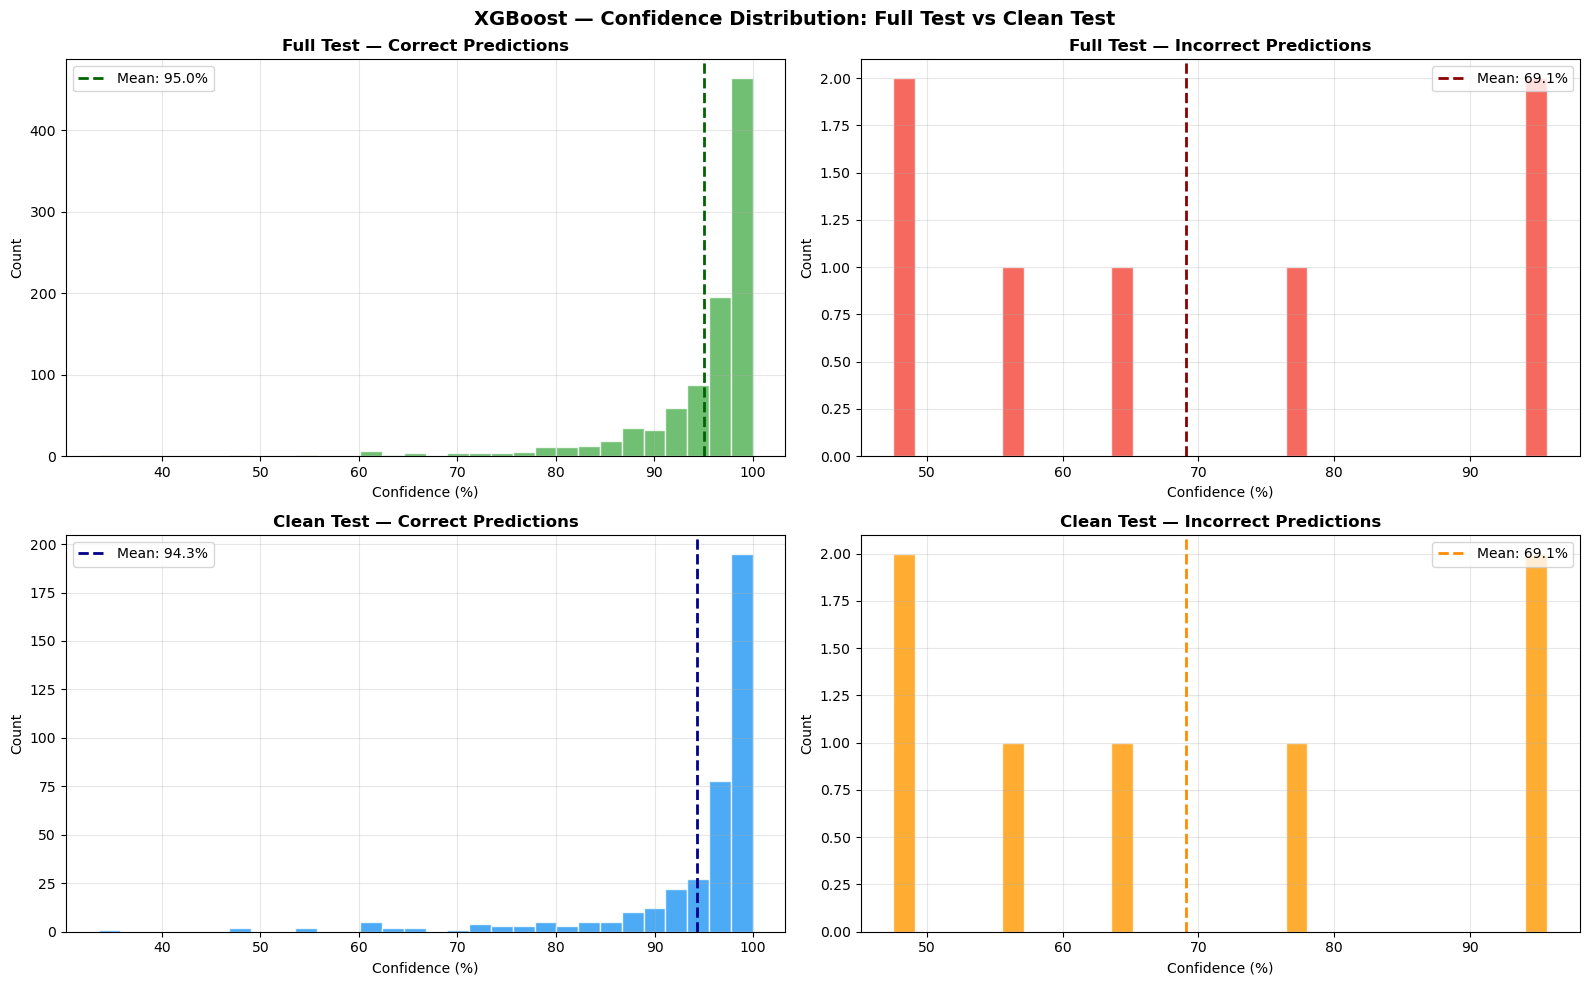

Confidence distribution comparison saved


In [12]:
def confidence_stats(preds, labels, probs, name):
    correct_mask_l   = preds == labels
    correct_conf_l   = probs[correct_mask_l].max(axis=1) * 100
    incorrect_conf_l = probs[~correct_mask_l].max(axis=1) * 100
    confident_wrong  = (incorrect_conf_l > 90).sum() if len(incorrect_conf_l) > 0 else 0

    print(f"\n  {name}:")
    print(f"    Correct   — Mean confidence : {correct_conf_l.mean():.1f}%  (n={correct_mask_l.sum()})")
    if len(incorrect_conf_l) > 0:
        print(f"    Incorrect — Mean confidence : {incorrect_conf_l.mean():.1f}%  (n={(~correct_mask_l).sum()})")
        print(f"    Confidently wrong (>90%)    : {confident_wrong}")
    else:
        print(f"    Incorrect — none!")
    return correct_conf_l, incorrect_conf_l


print(" CONFIDENCE DISTRIBUTION ANALYSIS")

full_correct_conf,  full_incorrect_conf  = confidence_stats(
    full_preds,  test_labels,  full_probs,  "Full Test Set")
clean_correct_conf, clean_incorrect_conf = confidence_stats(
    clean_preds, clean_labels, clean_probs, "Clean Test Set")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0][0].hist(full_correct_conf, bins=30, color='#4CAF50', alpha=0.8, edgecolor='white')
axes[0][0].axvline(full_correct_conf.mean(), color='darkgreen', linestyle='--',
                   linewidth=2, label=f'Mean: {full_correct_conf.mean():.1f}%')
axes[0][0].set_title('Full Test — Correct Predictions', fontsize=12, fontweight='bold')
axes[0][0].set_xlabel('Confidence (%)')
axes[0][0].set_ylabel('Count')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

axes[0][1].hist(full_incorrect_conf if len(full_incorrect_conf) > 0 else [0],
                bins=30, color='#F44336', alpha=0.8, edgecolor='white')
if len(full_incorrect_conf) > 0:
    axes[0][1].axvline(full_incorrect_conf.mean(), color='darkred', linestyle='--',
                       linewidth=2, label=f'Mean: {full_incorrect_conf.mean():.1f}%')
    axes[0][1].legend()
axes[0][1].set_title('Full Test — Incorrect Predictions', fontsize=12, fontweight='bold')
axes[0][1].set_xlabel('Confidence (%)')
axes[0][1].set_ylabel('Count')
axes[0][1].grid(True, alpha=0.3)

axes[1][0].hist(clean_correct_conf, bins=30, color='#2196F3', alpha=0.8, edgecolor='white')
axes[1][0].axvline(clean_correct_conf.mean(), color='darkblue', linestyle='--',
                   linewidth=2, label=f'Mean: {clean_correct_conf.mean():.1f}%')
axes[1][0].set_title('Clean Test — Correct Predictions', fontsize=12, fontweight='bold')
axes[1][0].set_xlabel('Confidence (%)')
axes[1][0].set_ylabel('Count')
axes[1][0].legend()
axes[1][0].grid(True, alpha=0.3)

axes[1][1].hist(clean_incorrect_conf if len(clean_incorrect_conf) > 0 else [0],
                bins=30, color='#FF9800', alpha=0.8, edgecolor='white')
if len(clean_incorrect_conf) > 0:
    axes[1][1].axvline(clean_incorrect_conf.mean(), color='darkorange', linestyle='--',
                       linewidth=2, label=f'Mean: {clean_incorrect_conf.mean():.1f}%')
    axes[1][1].legend()
axes[1][1].set_title('Clean Test — Incorrect Predictions', fontsize=12, fontweight='bold')
axes[1][1].set_xlabel('Confidence (%)')
axes[1][1].set_ylabel('Count')
axes[1][1].grid(True, alpha=0.3)

plt.suptitle('XGBoost — Confidence Distribution: Full Test vs Clean Test',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'xgb_confidence_distribution_comparison.png'), dpi=150)
plt.show()
print("Confidence distribution comparison saved")


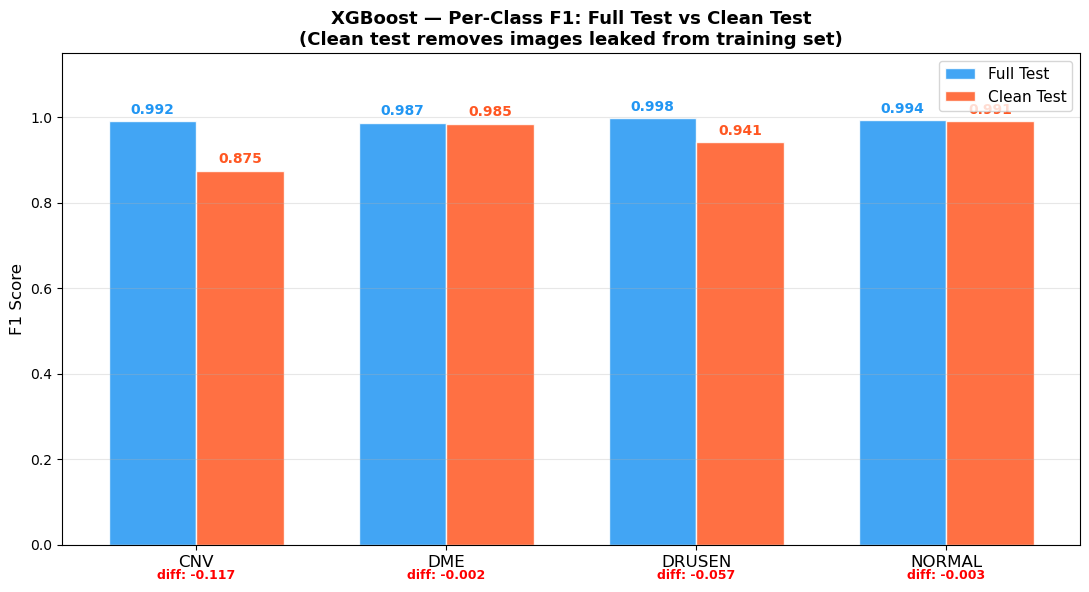


Per-Class F1 Comparison:
Class         Full Test   Clean Test   Difference
--------------------------------------------------
CNV              0.9918       0.8750      -0.1168
DME              0.9874       0.9852      -0.0022
DRUSEN           0.9979       0.9412      -0.0568
NORMAL           0.9938       0.9910      -0.0028
--------------------------------------------------
Macro Avg        0.9928       0.9481      -0.0447

Per-class F1 comparison chart saved


In [13]:
full_per_class_f1  = f1_score(test_labels,  full_preds,  average=None)
clean_per_class_f1 = f1_score(clean_labels, clean_preds, average=None)

x     = np.arange(len(CLASSES))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, full_per_class_f1,  width, label='Full Test',
               color='#2196F3', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, clean_per_class_f1, width, label='Clean Test',
               color='#FF5722', alpha=0.85, edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#2196F3')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#FF5722')

ax.set_xticks(x)
ax.set_xticklabels(CLASSES, fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('XGBoost — Per-Class F1: Full Test vs Clean Test\n'
             '(Clean test removes images leaked from training set)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for i in range(len(CLASSES)):
    diff  = clean_per_class_f1[i] - full_per_class_f1[i]
    color = 'red' if diff < 0 else 'green'
    ax.text(x[i], -0.08, f'diff: {diff:+.3f}',
            ha='center', fontsize=9, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'xgb_full_vs_clean_f1.png'), dpi=150)
plt.show()

print("\nPer-Class F1 Comparison:")
print(f"{'Class':<10} {'Full Test':>12} {'Clean Test':>12} {'Difference':>12}")
print("-"*50)
for i, cls in enumerate(CLASSES):
    diff = clean_per_class_f1[i] - full_per_class_f1[i]
    print(f"{cls:<10} {full_per_class_f1[i]:>12.4f} {clean_per_class_f1[i]:>12.4f} {diff:>+12.4f}")
print("-"*50)
print(f"{'Macro Avg':<10} {full_f1:>12.4f} {clean_f1:>12.4f} {clean_f1-full_f1:>+12.4f}")
print("\nPer-class F1 comparison chart saved")

In [14]:
print(" XGBOOST — FINAL SUMMARY")
print(f"\n  --- Full Test Set ---")
print(f"  Accuracy : {full_acc*100:.2f}%")
print(f"  Macro F1 : {full_f1:.4f}")
print(f"  AUC-ROC  : {full_auc:.4f}")
print(f"\n  --- Clean Test Set (leakage removed) ---")
print(f"  Accuracy : {clean_acc*100:.2f}%")
print(f"  Macro F1 : {clean_f1:.4f}")
print(f"  AUC-ROC  : {clean_auc:.4f}")
print(f"\n  --- Leakage Summary ---")
print(f"  Total test images : {total_test}")
print(f"  Leaked images     : {leaked_count} ({leaked_count/total_test*100:.1f}%)")
print(f"  Clean images      : {clean_count}  ({clean_count/total_test*100:.1f}%)")
print(f"\n  Best boosting round : {xgb_model.best_iteration}")
print(f"  Total trees built   : {xgb_model.best_iteration + 1}")
print(f"\n  Saved outputs:")
print(f"    results/xgb_class_weights.png")
print(f"    results/xgb_loss_curve.png")
print(f"    results/xgb_confusion_matrix.png")
print(f"    results/xgb_roc_curves.png")
print(f"    results/xgb_feature_importance.png")
print(f"    results/xgb_clean_test_confusion.png")
print(f"    results/xgb_confidence_distribution_comparison.png")
print(f"    results/xgb_full_vs_clean_f1.png")
print(f"    checkpoints/xgboost_model.pkl")

 XGBOOST — FINAL SUMMARY

  --- Full Test Set ---
  Accuracy : 99.28%
  Macro F1 : 0.9928
  AUC-ROC  : 0.9995

  --- Clean Test Set (leakage removed) ---
  Accuracy : 98.22%
  Macro F1 : 0.9481
  AUC-ROC  : 0.9983

  --- Leakage Summary ---
  Total test images : 968
  Leaked images     : 574 (59.3%)
  Clean images      : 394  (40.7%)

  Best boosting round : 298
  Total trees built   : 299

  Saved outputs:
    results/xgb_class_weights.png
    results/xgb_loss_curve.png
    results/xgb_confusion_matrix.png
    results/xgb_roc_curves.png
    results/xgb_feature_importance.png
    results/xgb_clean_test_confusion.png
    results/xgb_confidence_distribution_comparison.png
    results/xgb_full_vs_clean_f1.png
    checkpoints/xgboost_model.pkl
